# 4주차_데이터 탐색과 시각화 Ⅰ

- 비교 시각화

---

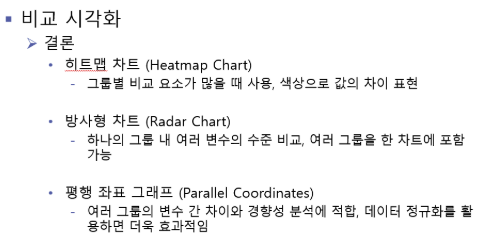

In [2]:
# 필요한 패키지 설치

import matplotlib.pyplot as plt
# 시각화를 위한 matplotlib의 pyplot 서브모듈을 불러옴

import pandas as pd
# 데이터프레임 조작을 위한 pandas 라이브러리를 불러옴

import datetime
# 날짜/시간 관련 처리를 위한 datetime 모듈 임포트

import seaborn as sns
# 통계적 시각화 기능을 강화한 seaborn 라이브러리 임포트

import numpy as np
# 수치 연산 및 배열 처리를 위한 numpy 라이브러리 임포트

from math import pi
# 방사형 차트에 필요한 파이값(pi)를 math 모듈에서 임포트

from pandas.plotting import parallel_coordinates
# 평행 좌표 시각화를 위한 pandas 내장 함수 임포트

plt.rcParams['figure.dpi'] = 300
# 출력되는 모든 그래프의 해상도를 300 DPI로 설정하여 시각 품질을 높임


In [19]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/umutalpaydn/nba-20202021-season-player-stats
df = pd.read_csv("../../main/datasets/nba2021_advanced.csv")

# 데이터 샘플 확인
df.head()

,Player,Pos,Age,Tm,G,MP,PER,TS%,3PAr,FTr,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,Precious Achiuwa,PF,21,MIA,28,408,15.1,0.599,0.000,0.541,...,16.1,19.7,0.3,0.6,0.9,0.101,-2.8,-0.2,-3.0,-0.1
1,Jaylen Adams,PG,24,MIL,6,17,-6.9,0.125,0.250,0.000,...,0.0,19.7,-0.1,0.0,-0.1,-0.265,-15.6,-5.2,-20.9,-0.1
2,Steven Adams,C,27,NOP,27,760,15.9,0.592,0.006,0.397,...,20.1,12.8,1.2,0.5,1.7,0.109,-0.1,-1.0,-1.1,0.2
3,Bam Adebayo,C,23,MIA,26,873,22.7,0.641,0.015,0.469,...,16.2,24.6,2.3,1.3,3.6,0.196,2.9,2.0,4.9,1.5
4,LaMarcus Aldridge,C,35,SAS,18,480,15.2,0.542,0.298,0.093,...,6.4,22.3,0.2,0.5,0.7,0.075,0.3,-1.0,-0.7,0.2


In [21]:
# 히트맵 시각화 V1을 위한 데이터 전처리

# 5개 팀만 필터링
df1 = df[df['Tm'].isin(['ATL','BOS','BRK','CHI','CHO'])]
# 'Tm' 컬럼은 각 선수의 소속 팀을 나타냄 (예: ATL = 애틀랜타 호크스)
# 전체 데이터 중에서 ATL, BOS, BRK, CHI, CHO 소속 선수들만 필터링함
# 너무 많은 팀을 동시에 시각화할 경우 그래프 해석이 어려우므로, 대표 5개 팀만 선택하여 시각화를 단순화함
# 팀 간 전술적 차이를 집중적으로 비교하고자 할 때 사용하는 전처리 기법임

# 6개 컬럼만 필터링 
df1 = df1[['Tm', 'ORB%','TRB%','AST%','BLK%','USG%']]
# 관심 있는 퍼포먼스 지표만 선택하여 사용함
# ORB% : Offensive Rebound Percentage (공격 리바운드 비율)
# TRB% : Total Rebound Percentage (전체 리바운드 비율)
# AST% : Assist Percentage (어시스트 비율)
# BLK% : Block Percentage (블록 성공 비율)
# USG% : Usage Percentage (공격 시 사용 비율, 얼마나 공격에 관여했는지)
# 'Tm' 컬럼은 팀 이름으로, 이후 그룹화 기준이 되므로 반드시 포함함
# 불필요한 열을 제거하고 시각화 대상 변수만 남겨 데이터 구조를 간결하게 만듦

# 팀 별 요소 평균 전처리
df1 = df1.groupby('Tm').mean()
# 동일 팀(Tm)에 속한 모든 선수들의 각 스탯 값을 평균냄
# 팀 단위 분석을 위해 선수 단위 데이터를 팀 단위 대표값으로 집계함
# 예: BOS 소속 모든 선수의 ORB%를 평균 내어 BOS의 대표 ORB%로 설정함
# 이렇게 하면 팀 전체의 전술적 특성과 플레이 스타일을 간단하게 파악할 수 있음
# 그룹화 후 평균을 취함으로써 데이터가 팀 단위로 재구성됨 (Tm은 인덱스로 이동됨)

df1.head()
# df1의 상위 5개 행을 출력하여 팀 단위 평균값이 올바르게 계산되었는지 확인함
# 출력 결과는 팀명을 인덱스로 하고, 각 팀의 5개 퍼포먼스 지표 평균을 열로 갖는 구조임

,ORB%,TRB%,AST%,BLK%,USG%
Tm,,,,,
ATL,5.250000,10.400000,13.893750,1.718750,18.412500
BOS,5.681250,10.362500,12.881250,2.437500,18.325000
BRK,4.394737,10.547368,15.210526,2.147368,18.868421
CHI,4.482353,10.976471,13.500000,1.405882,17.582353
CHO,7.628571,11.742857,14.900000,2.764286,19.357143


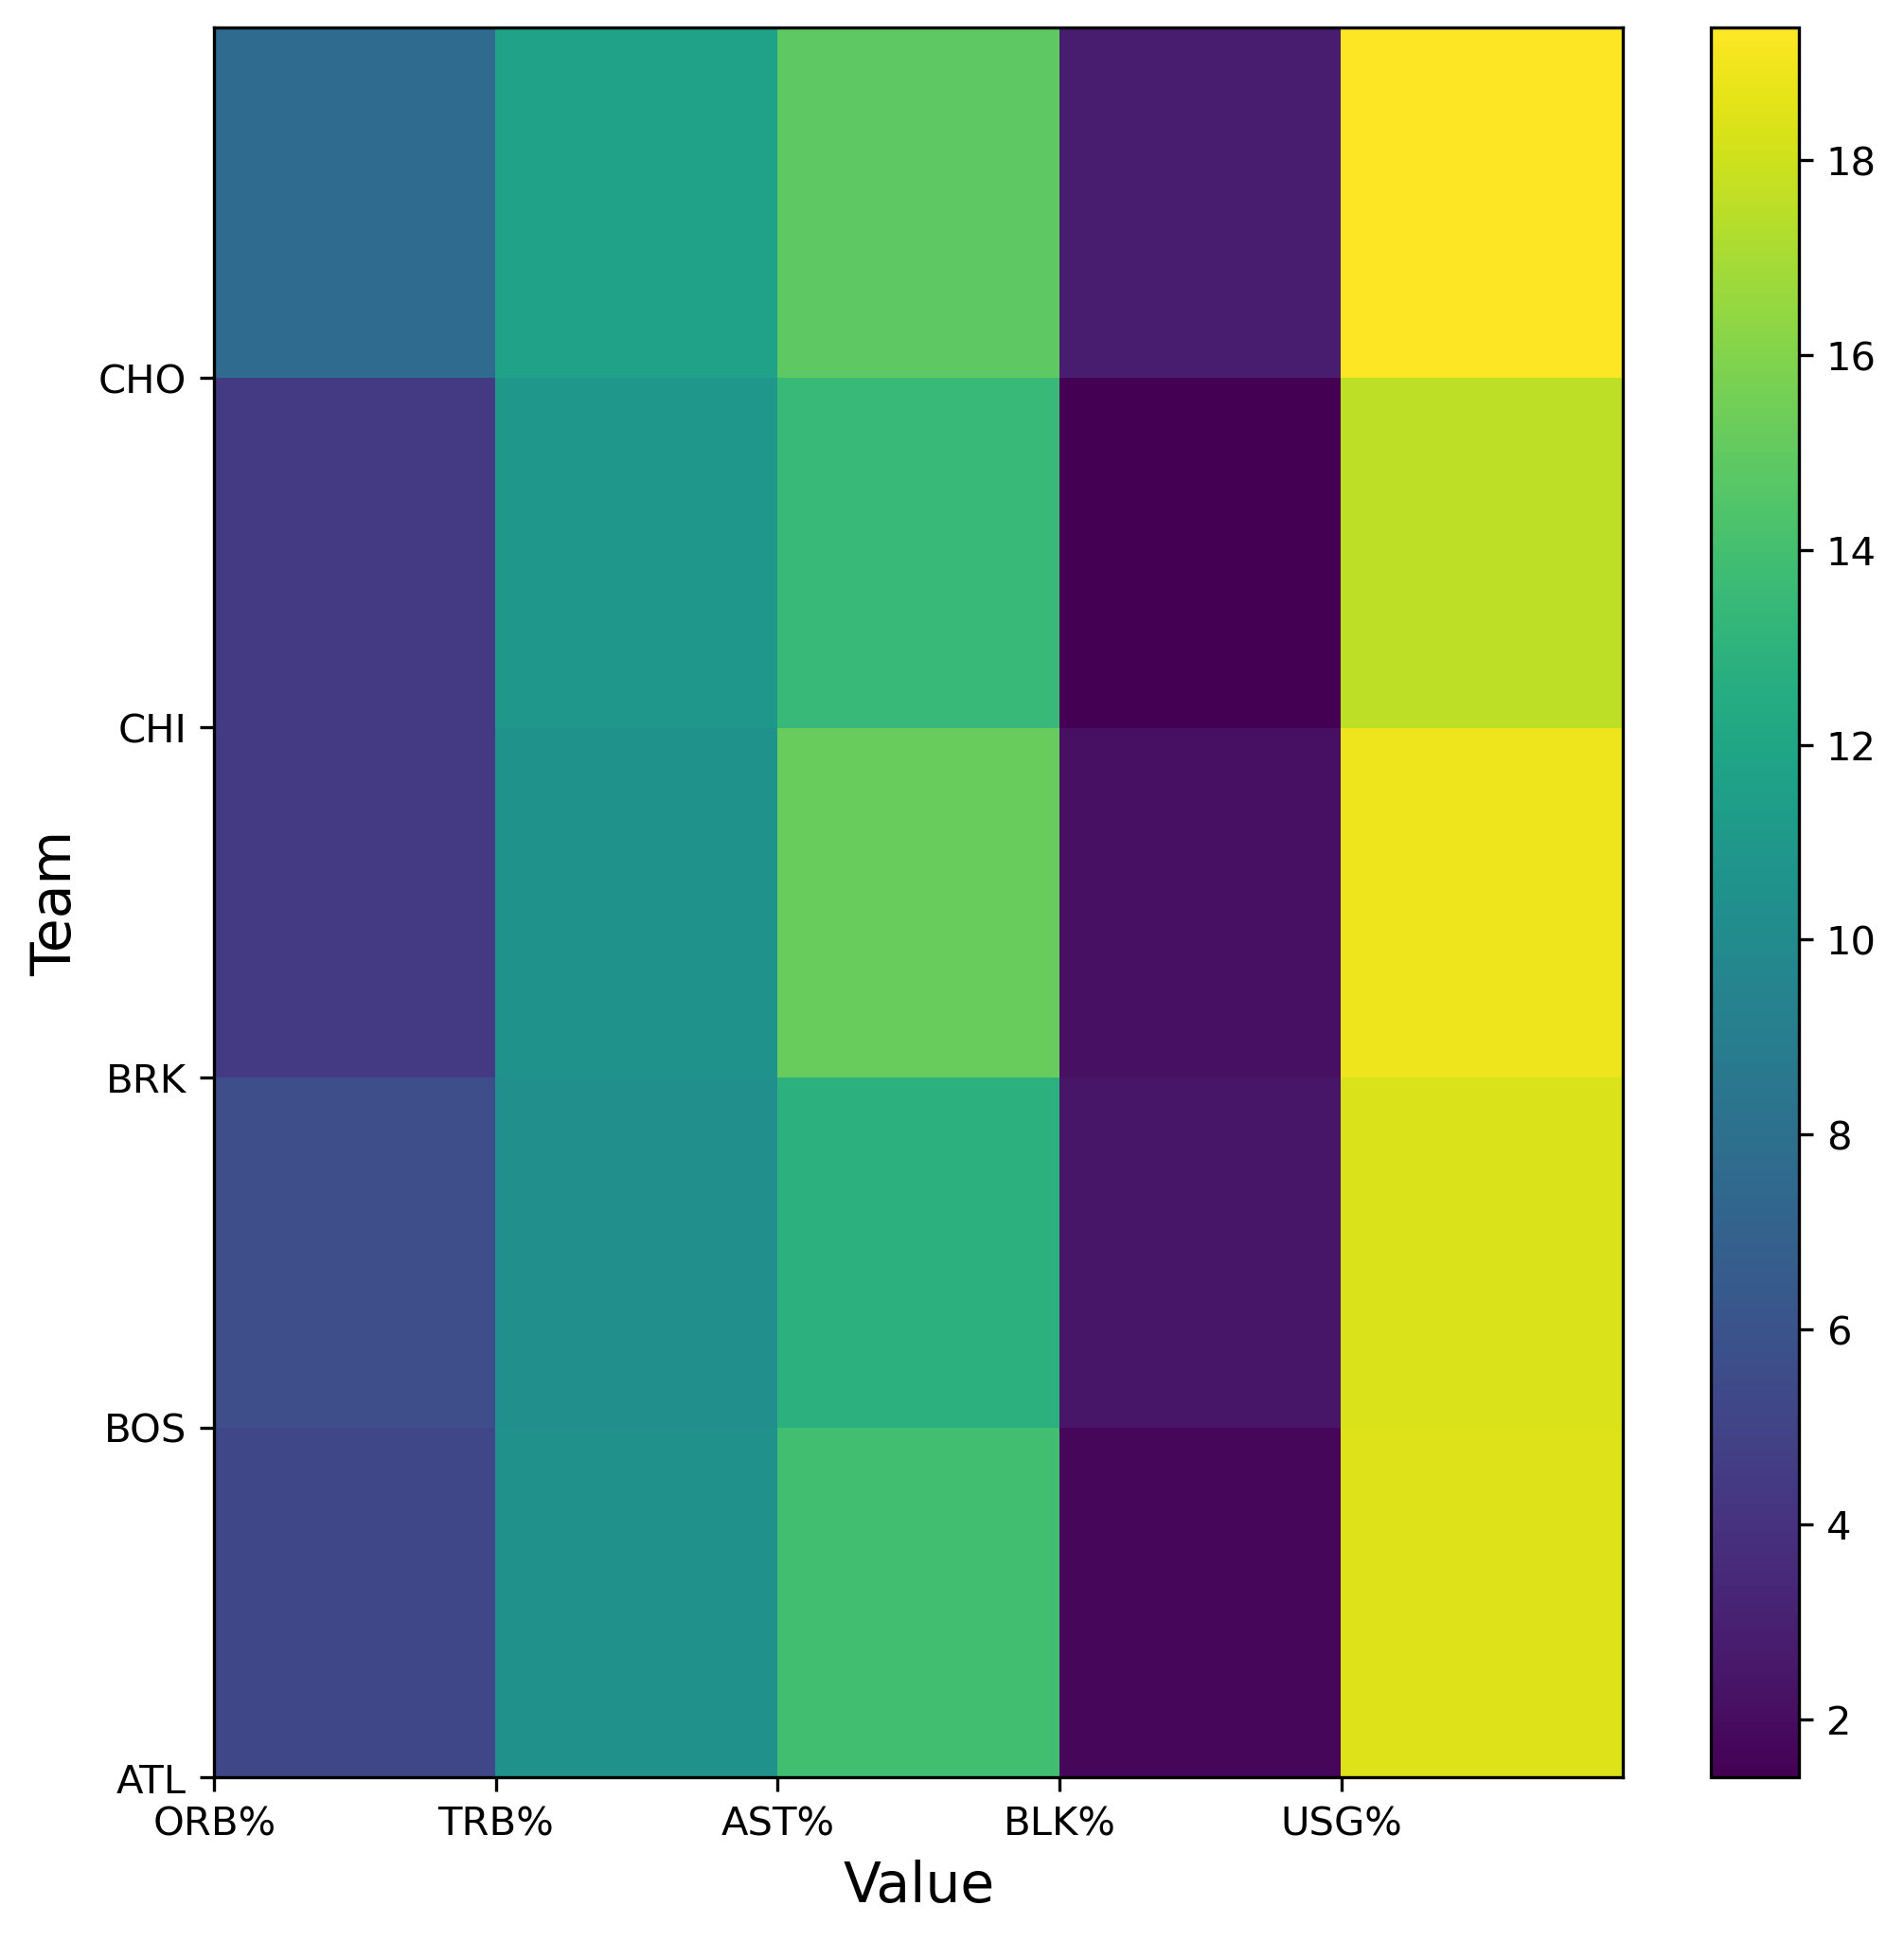

In [22]:
# 히트맵 시각화 V1

fig = plt.figure(figsize=(8,8))
# 시각화를 위한 matplotlib Figure 객체 생성
# figsize=(8,8)은 그래프의 가로 및 세로 크기를 각각 8인치로 설정하여 정사각형 형태로 구성함
# 그래프가 너무 작거나 길쭉하게 보이는 문제를 방지하고 균형 잡힌 시각화를 위한 설정임

fig.set_facecolor('white')
# 그래프의 전체 배경색을 흰색으로 설정함
# 기본 배경이 회색 또는 투명한 경우 시각적으로 혼란스러울 수 있으므로 명확한 배경 처리 수행함

plt.pcolor(df1.values)
# df1의 값(팀별 평균 스탯)을 색상으로 표현하는 격자 형태의 히트맵을 생성함
# 각 셀의 색상은 해당 값의 크기에 따라 자동으로 설정됨
# 이 그래프는 seaborn 없이 matplotlib만으로 생성된 가장 기본 형태의 히트맵임

# x축 컬럼 설정
plt.xticks(range(len(df1.columns)), df1.columns) 
# x축에 각 컬럼명을 표시함 (ORB%, TRB%, AST%, BLK%, USG%)
# range(len(df1.columns))은 x축 위치 지정, df1.columns는 레이블 이름으로 사용됨
# 각 열의 의미를 명확히 보여줘 어떤 지표에 해당하는지 시각적으로 판단 가능하게 함

# y축 컬럼 설정
plt.yticks(range(len(df1.index)), df1.index)
# y축에 각 팀명을 표시함 (ATL, BOS, BRK, CHI, CHO)
# df1은 Tm을 기준으로 그룹화된 상태이므로 인덱스가 팀 이름임
# 각 행이 어떤 팀에 해당하는지 명확하게 하기 위한 설정임

# x축 레이블 설정
plt.xlabel('Value', fontsize=14)
# x축 레이블로 'Value'를 설정하고 글꼴 크기를 14로 지정함
# 여기서 Value는 실제로는 컬럼명이므로 약간 모호할 수 있어 'Metrics' 등으로 수정 가능함

# y축 레이블 설정
plt.ylabel('Team', fontsize=14) 
# y축 레이블로 'Team'을 설정하고 글꼴 크기를 14로 지정함
# y축은 각 행이 어떤 팀인지 나타내므로 적절한 설명 라벨임

plt.colorbar()
# 그래프 우측에 색상값에 대한 컬러바(범례)를 추가함
# 색상의 농도와 값의 범위를 연결지어 해석을 도와줌
# 예: 진한 파란색은 낮은 값, 진한 빨간색은 높은 값을 나타냄

plt.show()
# 최종적으로 그래프를 출력함
# Jupyter 환경에서는 생략해도 출력되지만, 명시적으로 사용하면 호환성 및 명확성이 높아짐

In [23]:
# 히트맵 시각화 V2를 위한 데이터 전처리

# 5개 팀만 필터링
df2 = df[df['Tm'].isin(['ATL','BOS','BRK','CHI','CHO'])]
# 전체 선수 중에서 특정 5개 팀 소속 선수만 추출함 (ATL, BOS, BRK, CHI, CHO)
# 팀 간 비교를 단순화하고 그래프의 해석력을 높이기 위해 분석 범위를 제한함

# 팀명, 연령, 참여 게임 수 컬럼만 필터링
df2 = df2[['Tm','Age','G']]
# 시각화에 필요한 핵심 변수들만 선택함
# 'Tm'은 소속 팀, 'Age'는 선수 나이, 'G'는 해당 시즌 동안의 경기 출전 수를 의미함
# 각 팀의 연령대별 평균 출전 경향을 시각화하기 위해 필요한 최소한의 컬럼만 추출함

# 팀 - 연령 기준 평균으로 전처리
df2 = df2.groupby(['Tm','Age']).mean().reset_index()
# 팀과 나이대(Age) 별로 그룹화하여 해당 나이대 선수들의 평균 출전 경기 수를 계산함
# 예: BOS 소속 25세 선수들의 평균 출전 경기 수
# reset_index()는 그룹화 결과를 다시 일반적인 테이블 형태로 변환하여 피벗에 활용 가능하게 만듦

# 테이블 피벗
df2 = df2.pivot(index='Tm', columns='Age', values='G')
# 행은 팀(Tm), 열은 나이(Age), 값은 평균 경기 수(G)가 되도록 재구조화함
# 즉, 각 팀의 나이대별 평균 출전 경기 수를 행렬 형태로 표현함
# 이렇게 구성된 데이터는 히트맵으로 시각화하기 매우 적합하며, 팀의 로스터 운영 패턴을 분석하는 데 활용됨

df2.head()
# 피벗 결과 확인 — 각 행은 팀, 각 열은 특정 나이대, 셀 값은 해당 팀 소속 그 나이 선수들의 평균 출전 경기 수

Age,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34
Tm,,,,,,,,,,,,,,,
ATL,NaN,9.0,24.0,23.000000,16.250000,NaN,22.000000,25.0,NaN,9.0,21.5,NaN,NaN,16.0,14.0
BOS,NaN,NaN,13.0,20.000000,17.333333,26.0,6.000000,22.0,18.0,26.0,26.0,13.0,NaN,23.0,NaN
BRK,NaN,14.0,NaN,8.500000,26.000000,26.0,15.000000,12.0,3.0,16.5,30.0,NaN,16.0,23.5,30.0
CHI,26.0,27.0,8.5,15.000000,14.000000,7.0,16.500000,11.0,19.5,6.0,16.0,NaN,NaN,23.0,26.0
CHO,15.5,NaN,NaN,22.333333,9.000000,NaN,21.666667,26.0,NaN,20.5,NaN,26.0,NaN,NaN,NaN


/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_15292/1876639169.py:37: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


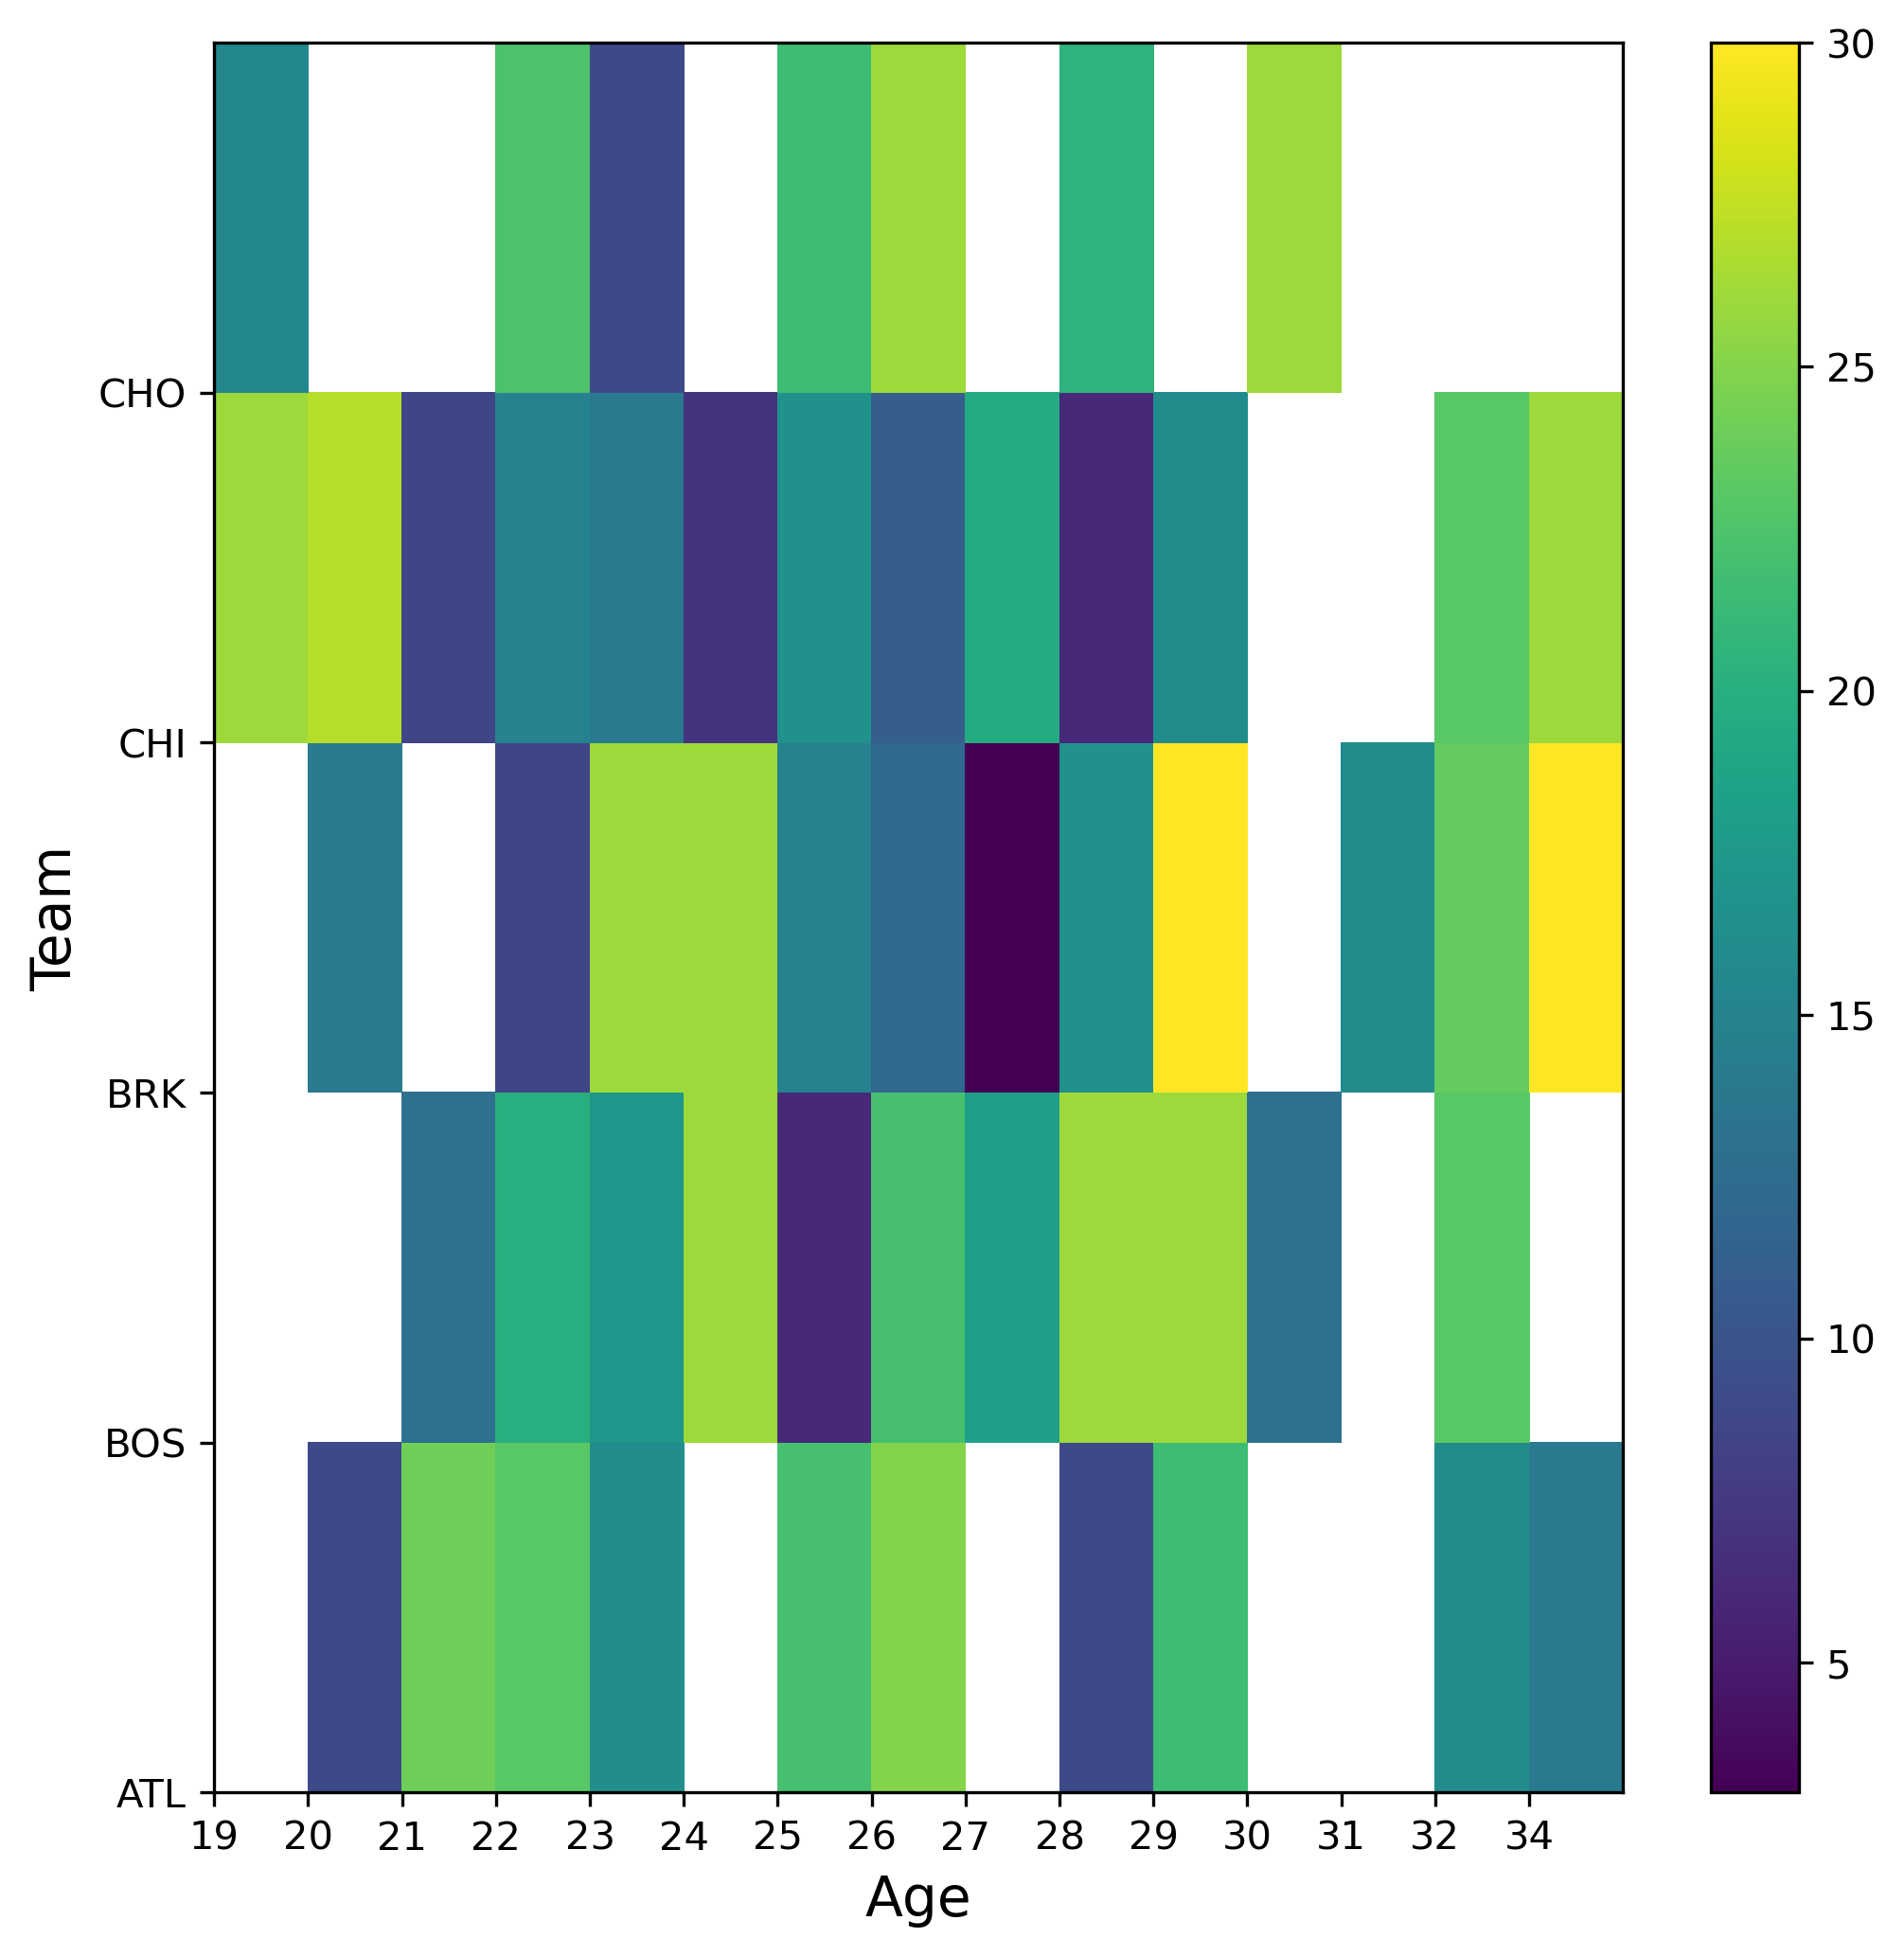

In [24]:
# 히트맵 시각화 V2

fig = plt.figure(figsize=(8,8))
# 8x8 인치 크기의 정사각형 Figure 객체를 생성함
# 출력되는 히트맵의 크기를 조절하여 축 라벨, 눈금, 색상 범례 등을 더 잘 표시할 수 있도록 함

fig.set_facecolor('white')
# Figure의 배경색을 흰색으로 설정함
# 발표 자료, 논문 등 시각화 결과물에서 깔끔한 배경을 위해 필수적으로 적용되는 설정임

plt.pcolor(df2.values)
# df2는 팀-연령 피벗 테이블로, values는 팀별 나이대 평균 출전 경기 수로 구성됨
# pcolor는 행렬 형태의 값을 색상 격자로 시각화하는 함수이며, 값이 클수록 색이 진해짐
# 이를 통해 각 팀이 어떤 연령대의 선수들에게 많은 출전 기회를 부여하는지 시각적으로 표현할 수 있음

# x축 컬럼 설정
plt.xticks(range(len(df2.columns)), df2.columns)
# x축 위치를 0부터 컬럼 수만큼 지정하고, 실제 눈금 라벨로 나이대(df2.columns)를 표시함
# 예: x축에 20세, 21세, ..., 35세 등의 나이대가 순서대로 배치됨
# 히트맵의 열 방향 해석을 가능하게 하기 위한 라벨링 처리임

# y축 컬럼 설정
plt.yticks(range(len(df2.index)), df2.index)
# y축 위치를 0부터 행 수만큼 지정하고, 실제 눈금 라벨로 팀명(df2.index)을 표시함
# 행마다 ATL, BOS 등 팀 이름이 대응되며, 어떤 팀의 데이터를 보는지 구분할 수 있음

# x축 레이블 설정
plt.xlabel('Age', fontsize=14)
# x축 전체에 대한 설명 레이블로 'Age'를 설정하고, 글꼴 크기를 14로 지정함
# x축이 선수 나이 분포임을 명확하게 표시함

# y축 레이블 설정
plt.ylabel('Team', fontsize=14)
# y축 전체에 대한 설명 레이블로 'Team'을 설정하고, 글꼴 크기를 14로 지정함
# y축이 NBA 팀을 의미함을 명확하게 표현함

plt.colorbar()
# 그래프 오른쪽에 색상 범례를 추가함
# 색이 어떤 값 범위를 나타내는지를 시각적으로 해석할 수 있도록 도와주는 중요 요소임
# 예: 색이 진할수록 해당 팀의 그 나이대 선수들이 평균적으로 더 많은 경기를 출전했음을 의미함

plt.show()
# 최종 그래프를 출력함
# 모든 설정과 시각화 요소를 포함한 완성된 히트맵을 화면에 렌더링함


In [ ]:
# 방사형 차트를 위한 인덱스 초기화
df3 = df1.reset_index()
# df1은 이전에 팀별 평균 퍼포먼스 지표(ORB%, TRB%, AST%, BLK%, USG%)를 계산한 데이터프레임이며
# 현재 팀명(Tm)이 인덱스로 설정되어 있음 → 방사형 차트를 그릴 때 팀명을 일반 컬럼으로 사용해야 하므로 인덱스를 초기화함
# reset_index()를 통해 팀명(Tm)을 인덱스에서 일반 컬럼으로 변환하고, 0부터 시작하는 새로운 정수 인덱스를 생성함
# 이 과정을 통해 방사형 차트에서 팀명을 레이블로 활용할 수 있는 구조로 전환함

df3.head()
# 인덱스 초기화가 정상적으로 되었는지 확인하기 위해 상위 5개 행을 출력함
# 출력 결과에는 'Tm'이라는 컬럼이 포함되고, 나머지 퍼포먼스 지표 컬럼은 그대로 유지된 상태임


,Tm,ORB%,TRB%,AST%,BLK%,USG%
0,ATL,5.250000,10.400000,13.893750,1.718750,18.412500
1,BOS,5.681250,10.362500,12.881250,2.437500,18.325000
2,BRK,4.394737,10.547368,15.210526,2.147368,18.868421
3,CHI,4.482353,10.976471,13.500000,1.405882,17.582353
4,CHO,7.628571,11.742857,14.900000,2.764286,19.357143


/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_15292/2713511128.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(df3.index))


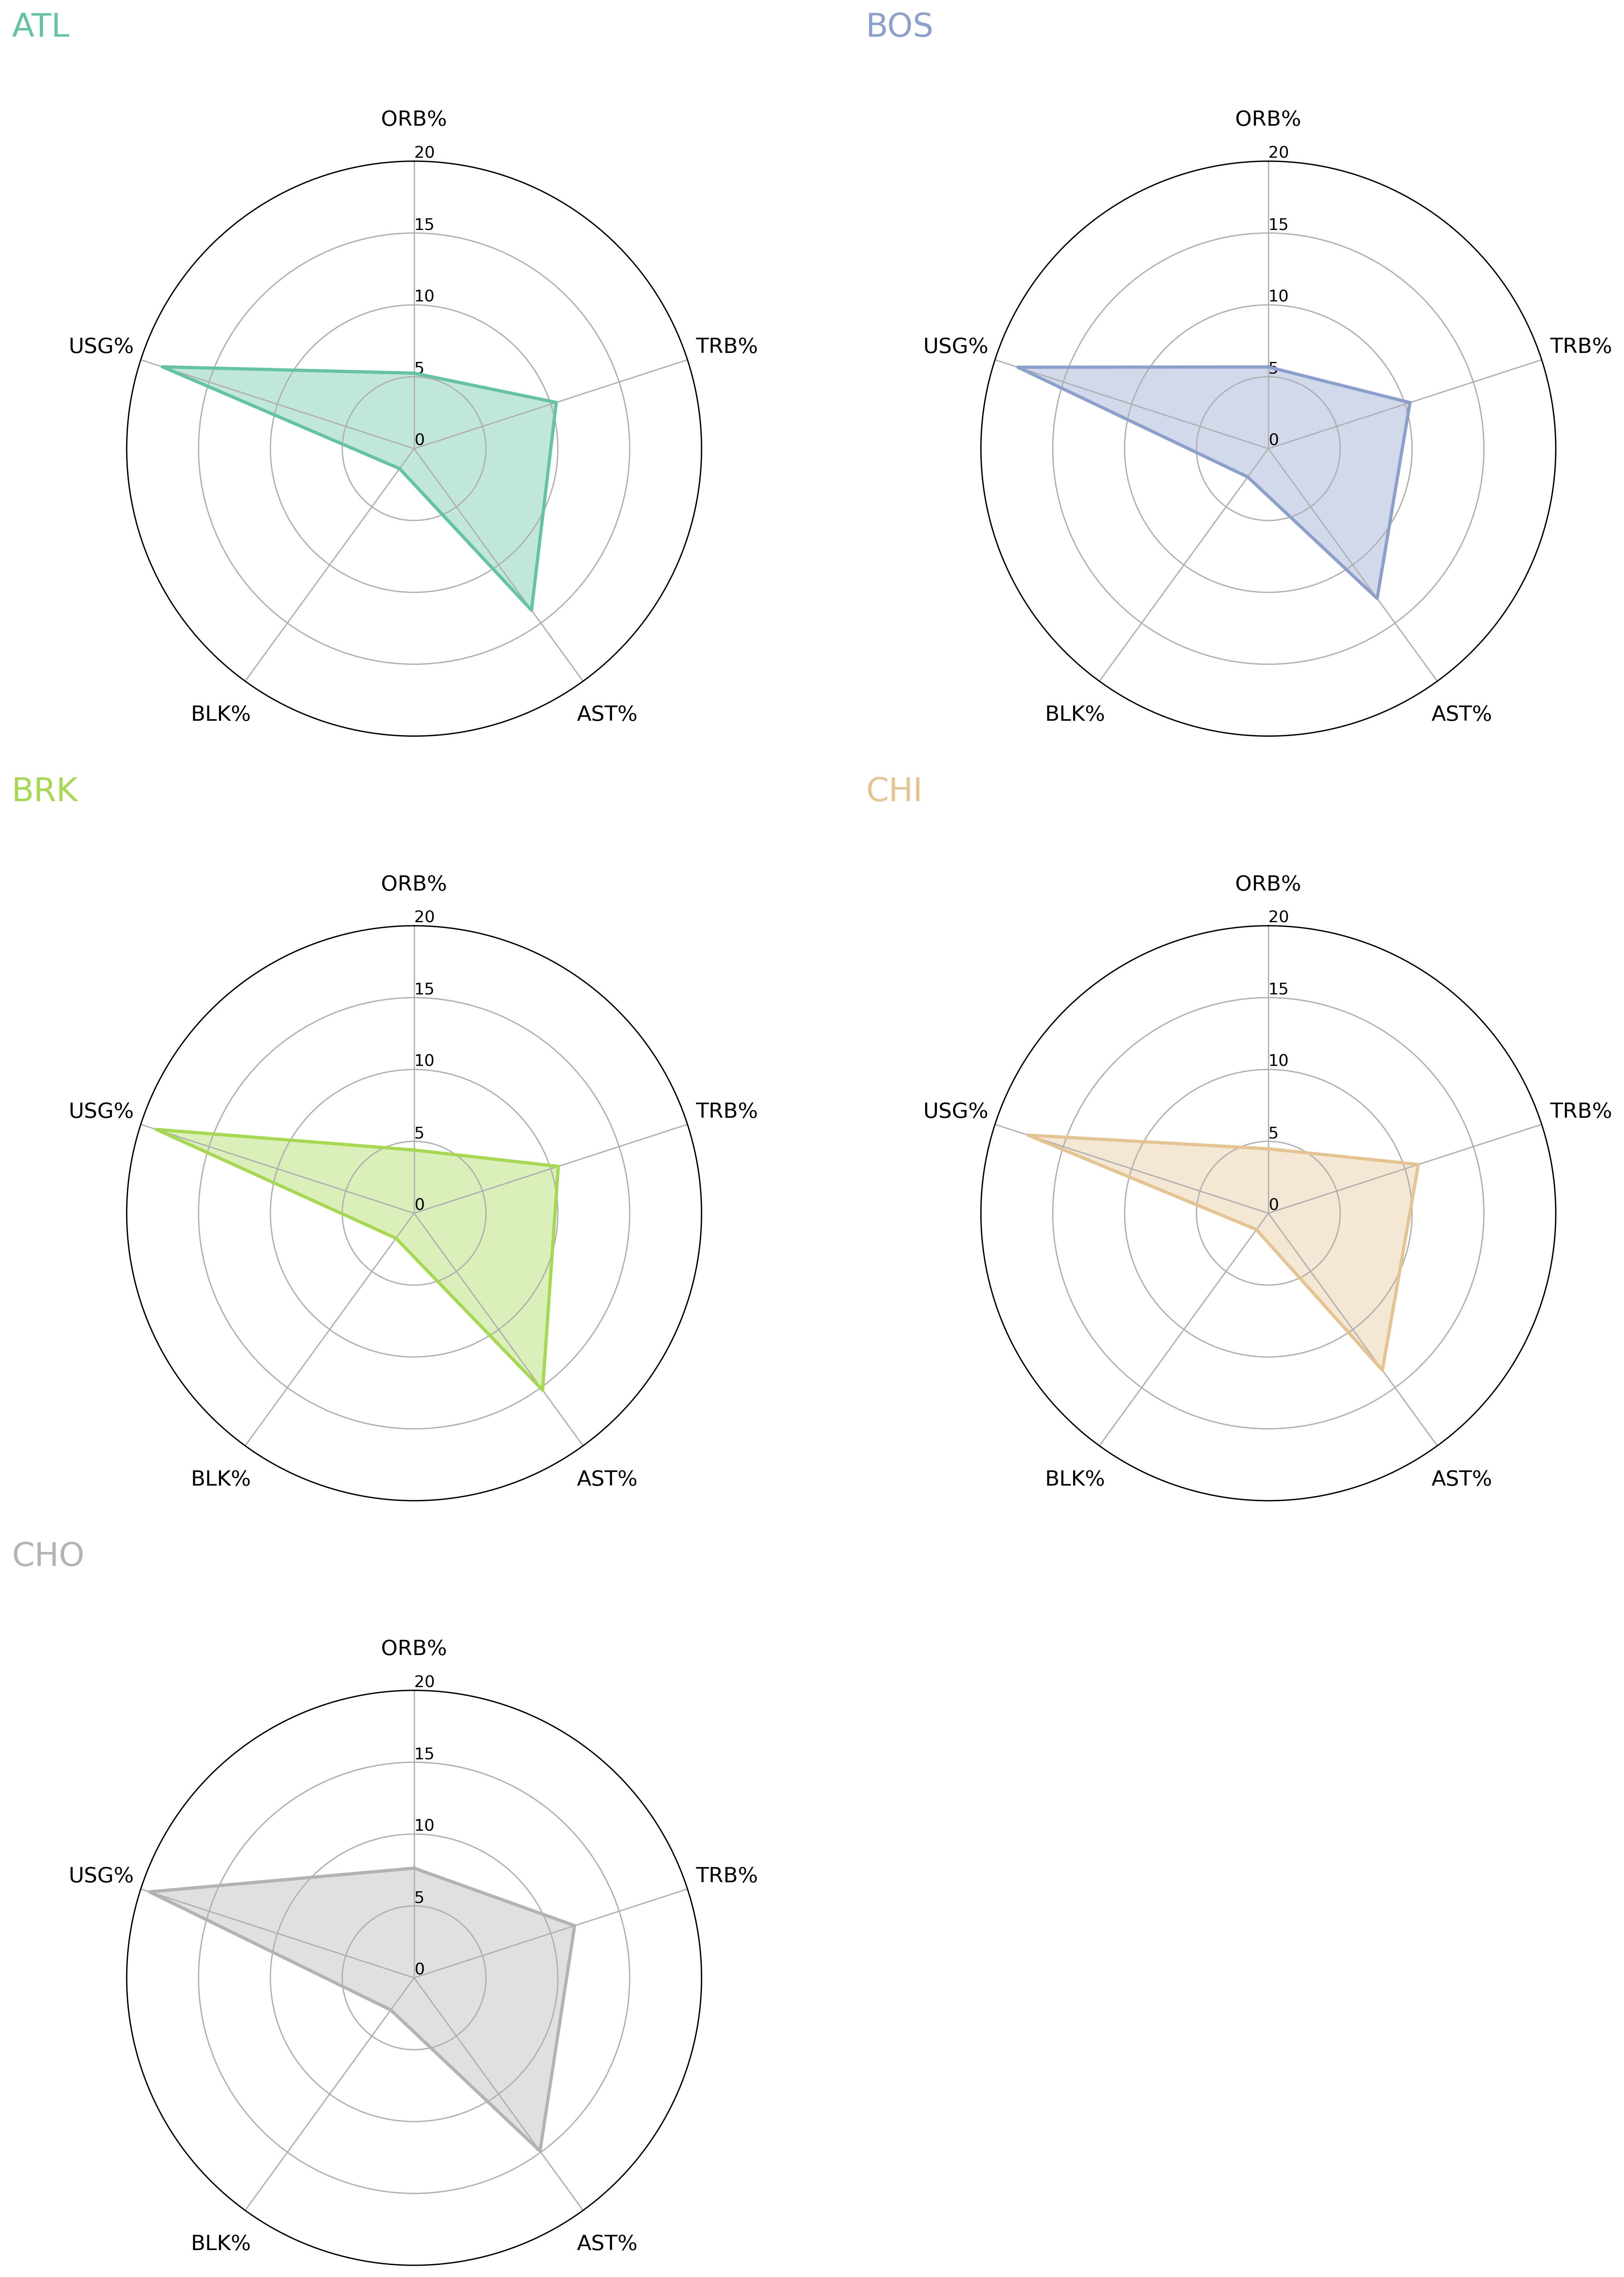

In [33]:
# 방사형 차트 - 하나씩 시각화

labels = df3.columns[1:]
# 'df3'은 팀별 평균 스탯 데이터프레임으로, 첫 번째 컬럼은 'Tm'(팀명), 이후는 스탯 지표들임
# 'labels' 변수에는 방사형 차트의 축이 될 지표 이름들만 저장함 (예: ORB%, TRB%, AST%, BLK%, USG%)

num_labels = len(labels)
# 사용할 지표의 수(축 개수)를 계산함
# 추후 각도를 지표 수에 맞게 등분하기 위한 기초 정보로 활용됨

# 등분점 생성    
angles = [x / float(num_labels) * (2 * pi) for x in range(num_labels)] 
# 전체 원(2π radian = 360도)을 지표 수만큼 나눠서 각 축이 차지할 각도를 리스트로 계산함
# 예: 5개 지표라면 [0, 72°, 144°, 216°, 288°]와 같은 등분된 각도 생성됨 (radian 단위)

angles += angles[:1] 
# 다각형을 닫기 위해 시작점(0도) 좌표를 리스트의 끝에 다시 추가함
# 이렇게 하지 않으면 그래프가 열린 형태로 시각화됨
# angles += angles[:1]	X축 각도 좌표 (radian)	방사형 그래프에서 축을 원형으로 닫기 위함
# angles += angles[:1] → [0, 72°, 144°, 216°, 288°, 0]으로 만들어 선을 시작점으로 되돌림

my_palette = plt.cm.get_cmap("Set2", len(df3.index))
# 팀 개수만큼 고유 색상을 생성하는 색상 팔레트 지정
# 'Set2'는 matplotlib의 미리 정의된 부드러운 색상 계열 중 하나로, 시각적으로 구분이 잘 되는 컬러셋임

fig = plt.figure(figsize=(15, 20))
# 전체 figure 객체 생성 및 사이즈 지정
# 15x20인치는 매우 큰 사이즈로, 각 팀별 방사형 차트를 넉넉한 공간에 출력하기 위함

fig.set_facecolor('white')
# figure 전체의 배경색을 흰색으로 설정함
# 출력물의 시인성 향상 및 프레젠테이션용 자료와의 조화를 위해 기본 설정

for i, row in df3.iterrows():
    # df3 데이터프레임의 각 행을 순회함 (각 행은 하나의 팀에 해당함)

    color = my_palette(i)
    # 현재 팀에 고유 색상을 할당함
    # 색상은 Set2 팔레트에서 인덱스(i)를 기반으로 순차적으로 선택됨

    data = df3.iloc[i].drop('Tm').tolist()
    # 현재 팀의 퍼포먼스 지표 값만 추출함 (Tm은 제외)
    # 방사형 차트를 구성할 실제 값 목록을 리스트 형태로 변환함

    data += data[:1]
    # 리스트의 첫 번째 값을 맨 끝에 추가하여 다각형의 시작점과 끝점을 연결함
    # 이 처리를 통해 도형이 완전히 닫힌 상태로 시각화됨
    # data += data[:1]	실제 데이터 값 (지표 값)	첫 값으로 다시 돌아가 도형의 경계선이 닫히도록 함
    # data += data[:1] → 데이터도 [10, 8, 12, 7, 9] → [10, 8, 12, 7, 9, 10]으로 시작값 반복

    ax = plt.subplot(3, 2, i + 1, polar=True)
    # 3행 2열 형태의 서브플롯 그리드 중 하나를 차지하도록 설정하고, polar=True로 극좌표계(방사형 차트) 활성화
    # subplot(3, 2, i+1): 각 팀이 별도의 그래프에 그려지도록 배치함

    ax.set_theta_offset(pi / 2)
    # 첫 번째 축(지표)이 위쪽(12시 방향)에 오도록 회전 설정함 (기본은 오른쪽에서 시작)

    ax.set_theta_direction(-1)
    # 축을 시계 방향으로 설정함 (기본은 반시계 방향)
    # 각 축이 순차적으로 오른쪽 방향으로 배치되도록 시각적으로 자연스럽게 만듦

    plt.xticks(angles[:-1], labels, fontsize=13)
    # 방사형 차트의 각 축에 지표 이름(ORB%, TRB%, ...)을 표시함
    # 마지막 각도는 시작점이므로 중복 제거를 위해 제외하고 라벨링함

    ax.tick_params(axis='x', which='major', pad=15)
    # 축과 라벨 간 간격을 조정하여 축 제목들이 도형 내부로 너무 붙지 않도록 여백 확보

    ax.set_rlabel_position(0)
    # 방사형의 반지름 방향 눈금(0, 5, 10, ...)의 라벨이 항상 위쪽을 바라보도록 위치 고정
    # 가독성을 높이고 모든 subplot에서 일관성 있는 시각화 유지

    plt.yticks([0, 5, 10, 15, 20], ['0', '5', '10', '15', '20'], fontsize=10) 
    # 반지름 축의 눈금을 수동 설정함 (값, 표시 텍스트, 글꼴 크기)
    # 모든 차트에서 동일한 눈금 간격을 유지하여 비교 가능성을 확보함

    plt.ylim(0, 20)
    # 반지름 값의 최대 범위를 20으로 설정하여 스케일을 고정함
    # 팀 간 데이터 차이가 과도하게 확대되지 않도록 제어함

    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    # 앞서 계산한 각도와 스탯 값을 연결한 선을 그려 방사형 차트를 생성함
    # 선의 색상은 팀 고유 색, 두께는 2, 선 스타일은 실선으로 설정함

    ax.fill(angles, data, color=color, alpha=0.4)
    # 방사형 차트 내부를 반투명 색상으로 채움
    # 도형의 면적을 통해 시각적 강조를 추가함 (alpha는 투명도)

    plt.title(row.Tm, size=20, color=color, x=-0.2, y=1.2, ha='left')
    # 방사형 차트 상단 외부에 팀명을 제목으로 설정함
    # 좌표(x, y)와 정렬 방식(ha)을 조절하여 제목이 각 차트 상단 왼쪽에 균일하게 위치함
    # 색상은 해당 팀의 도형 색상과 동일하게 하여 시각적 연결감을 제공함

plt.tight_layout(pad=3)
# subplot 간의 간격을 자동 조정하여 도형끼리 겹치지 않도록 정렬함
# pad=3은 subplot 간 여백 설정 값임

plt.show()
# 전체 그래프를 출력함
# 각 팀의 전술적 특성을 방사형 차트로 시각화하여 비교할 수 있게 완성된 그래프를 화면에 렌더링함


/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_15292/2640898949.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(df3.index))


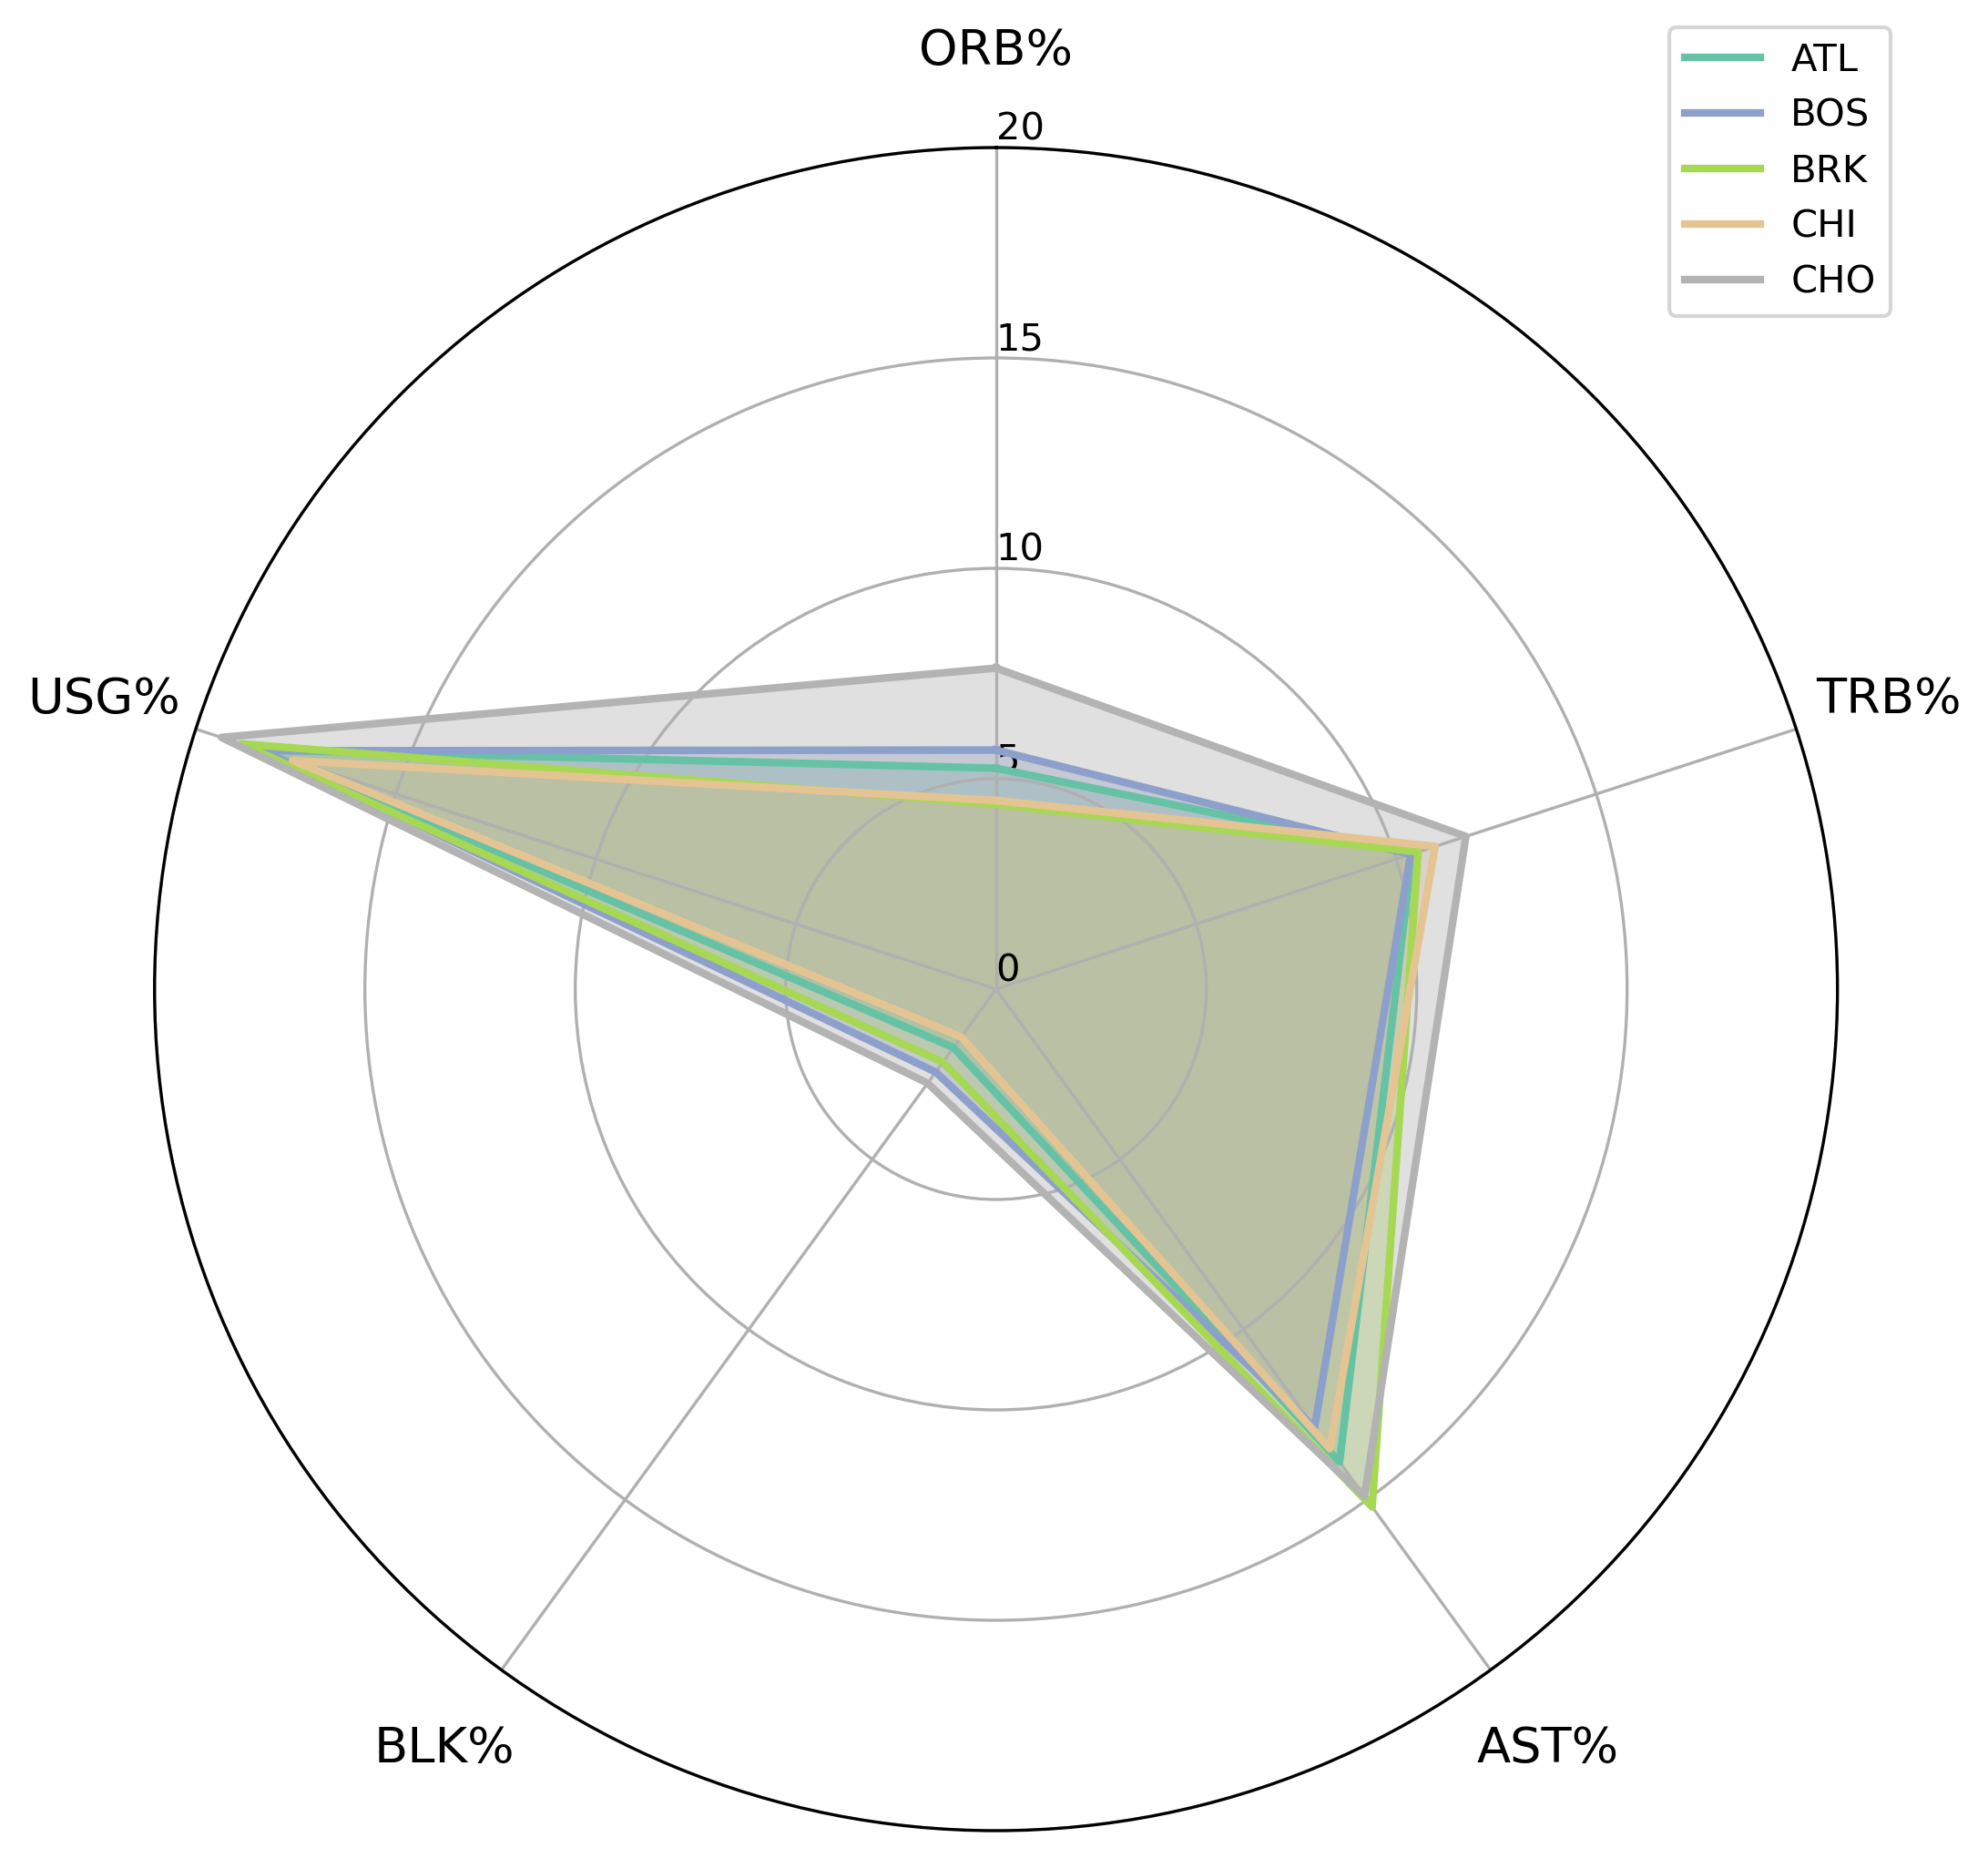

In [ ]:
# 방사형 차트 - 한번에 시각화


# ┌───────────────────────────────┬──────────────────────────────────────────┐
# │           목적                │                        예시                │
# ├───────────────────────────────┼─────────────────────────────────────────┤
# │ 팀 간 전술적 유사성 확인      │ 비슷한 도형 형태를 가진 팀은 유사한 플레이 스타일을 가짐  │
# │ 특정 지표에서의 두드러진 차이 │ 한 팀만 AST%가 확 튀는 경우, 패스 위주의 전술 사용 가능성 │
# │ 밸런스 분석                  │ 거의 원형에 가까운 팀은 전반적으로 고른 능력 분포를 보임 │
# └───────────────────────────────┴────────────────────────────────────────┘


labels = df3.columns[1:]
# 'df3'의 첫 번째 컬럼은 'Tm'(팀명)이고, 나머지 컬럼들이 방사형 축의 지표들임
# 방사형 차트의 각 축에 배치될 퍼포먼스 지표 이름들만 따로 추출함

num_labels = len(labels)
# 방사형 차트에서 사용될 지표 개수 계산 (축 개수 = 지표 수)

# 등분점 생성
angles = [x / float(num_labels) * (2 * pi) for x in range(num_labels)]
# 원의 전체 각도(2π 라디안 = 360도)를 지표 개수로 등분하여 각 축의 각도를 계산함
# 예: 5개의 지표 → 0°, 72°, 144°, 216°, 288°와 같은 각도 생성

# 시작점 생성
angles += angles[:1]
# 도형을 닫기 위해 시작점(첫 번째 각도)를 리스트의 끝에 다시 추가함

my_palette = plt.cm.get_cmap("Set2", len(df3.index))
# 팀 수만큼 구분 가능한 색상 팔레트를 생성함 (Set2는 잘 구분되는 밝은 계열의 컬러맵)

fig = plt.figure(figsize=(8, 8))
# 전체 figure 크기를 8x8 인치로 설정함
# 한 개의 방사형 차트에 여러 팀 데이터를 동시에 보여주므로 적당한 크기 설정이 중요함

fig.set_facecolor('white')
# figure 배경을 흰색으로 설정하여 깔끔한 시각화 제공

ax = fig.add_subplot(polar=True)
# 하나의 서브플롯을 생성함, polar=True로 극좌표계(방사형 차트)를 활성화함
# 이 영역에 모든 팀의 차트를 겹쳐 그리게 됨

for i, row in df3.iterrows():
    # df3의 각 행을 순회하며, 한 팀씩 방사형 차트에 추가함

    color = my_palette(i)
    # 현재 팀에 고유 색상을 할당함 (인덱스를 기반으로 색상 선택)

    data = df3.iloc[i].drop('Tm').tolist()
    # 현재 팀의 스탯 값들만 리스트로 추출함 ('Tm'은 제외함)

    data += data[:1]
    # 다각형을 닫기 위해 첫 번째 값을 마지막에 추가함

    # 시작점
    ax.set_theta_offset(pi / 2)
    # 첫 번째 축이 12시 방향에 오도록 설정함

    # 시계방향 설정
    ax.set_theta_direction(-1)
    # 축을 시계 방향으로 배치함

    # 각도 축 눈금 생성
    plt.xticks(angles[:-1], labels, fontsize=13)
    # 각 축에 지표명을 표시함 (마지막은 중복되므로 제외)

    # 각 축과 눈금 사이 여백생성
    ax.tick_params(axis='x', which='major', pad=15)
    # 지표명과 원 사이 간격을 벌려 가독성 향상

    # 반지름 축 눈금 라벨 각도 0으로 설정 
    ax.set_rlabel_position(0)
    # 반지름 축 눈금이 위쪽을 기준으로 배치되도록 설정함

    # 반지름 축 눈금 설정
    plt.yticks([0, 5, 10, 15, 20], ['0', '5', '10', '15', '20'], fontsize=10)
    # 반지름 눈금 설정 — 모든 팀이 같은 눈금 기준을 사용함으로써 비교 가능성 확보

    plt.ylim(0, 20)
    # 반지름 최대 값 고정 (모든 지표가 이 범위 내에 있으므로 스케일을 일관성 있게 유지함)

    # 방사형 차트 출력
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid', label=row.Tm)
    # 선으로 팀의 지표 연결하여 다각형 생성
    # label=row.Tm 은 범례에서 팀명을 표시하기 위해 사용됨

    # 도형 안쪽 색상 설정
    ax.fill(angles, data, color=color, alpha=0.4)
    # 해당 팀 다각형 내부를 반투명하게 채워 색으로 식별 가능하게 함

plt.legend(loc=(0.9, 0.9))
# 우측 상단에 범례 표시하여 각 색상이 어떤 팀을 의미하는지 확인할 수 있게 함
# loc은 그래프 기준 상대 좌표로 범례 위치 조정 (0.9, 0.9 → 오른쪽 위)

plt.show()
# 방사형 차트를 화면에 출력함
# 하나의 그래프 위에 여러 팀의 퍼포먼스 구조를 동시에 비교할 수 있게 완성함


<Axes: >

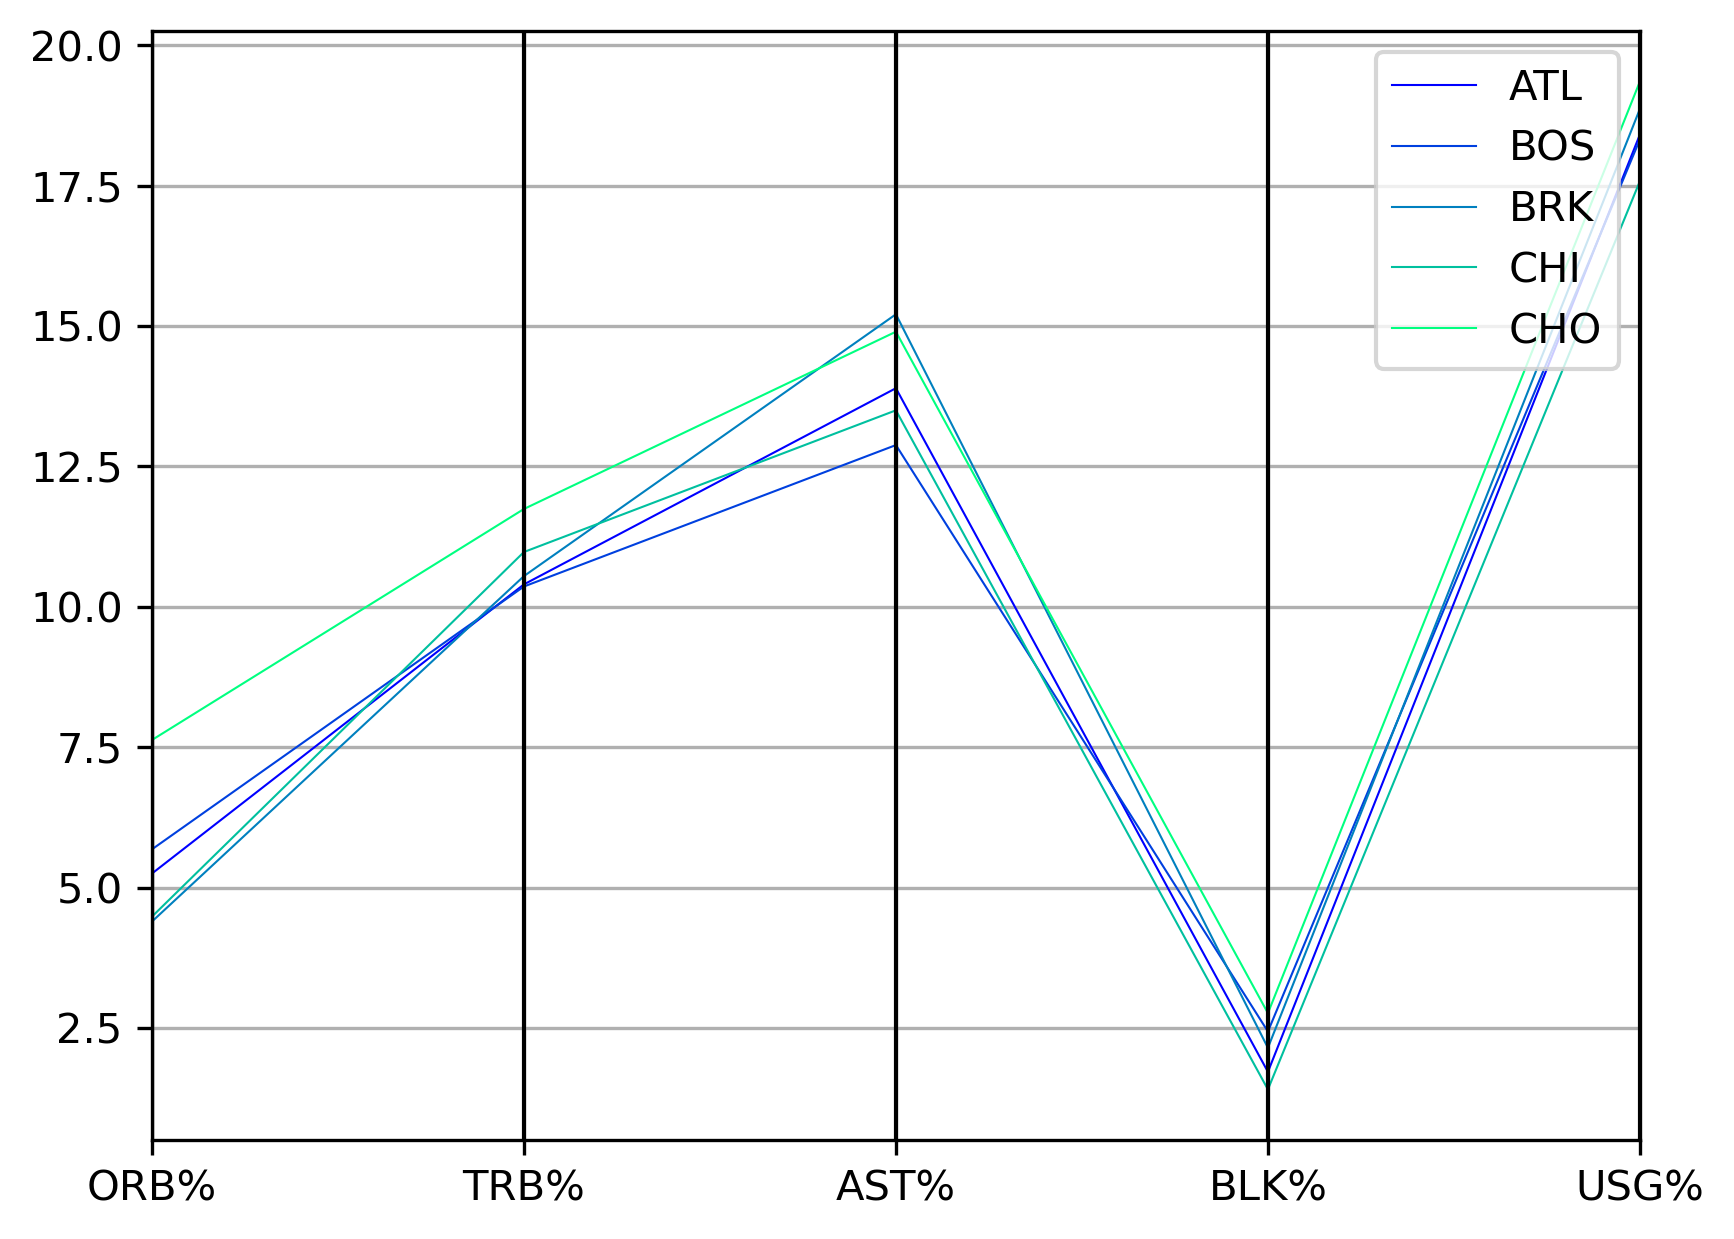

<Figure size 4800x2400 with 0 Axes>

In [ ]:
# 팀 기준 평행 좌표 그래프 생성

fig, axes = plt.subplots()
# 하나의 subplot을 생성하고, 반환된 figure와 axes 객체를 각각 fig와 axes에 저장함
# 이 axes 객체를 통해 이후의 평행 좌표 그래프가 어디에 그려질지를 지정함

plt.figure(figsize=(16,8)) 
# 전체 figure의 크기를 가로 16인치, 세로 8인치로 설정함
# 평행 좌표 그래프는 다수의 축을 가로로 늘어놓기 때문에 넓은 가로폭이 필요함
# 충분한 공간 확보로 라벨 겹침 방지 및 가독성 향상을 위함

# parallel_coordinates는 다차원(다변수) 데이터를 시각화하는 기법 중 하나로, 
# 여러 수치형 변수를 평행한 축들 위에 배치하고,
# 각 데이터 인스턴스를 선 하나로 표현하여 변수 간의 상대적 크기나 패턴 차이를 시각적으로 파악할 수 있게 도와줌.

parallel_coordinates(
    df3,              # 데이터프레임: 팀명(Tm)과 각 팀의 평균 스탯 지표가 포함됨
    'Tm',             # 클래스(범례 기준 컬럼): 'Tm'을 기준으로 팀별로 색상을 다르게 표시함
    ax=axes,          # 위에서 생성한 axes 객체에 평행 좌표 그래프를 그리도록 지정함
    colormap='winter',# 팀별 선 색상을 지정하는 컬러맵 설정 ('winter'는 파란~연녹 계열 색상)
    linewidth=0.5     # 각 팀을 나타내는 선의 두께를 0.5로 얇게 설정하여 복잡도 완화
)
# 각 팀은 하나의 꺾은선으로 표현되며, 각 축은 ORB%, TRB%, AST%, BLK%, USG% 등 지표임
# 팀별 선이 축 사이를 어떻게 이동하는지를 통해 지표 간 상대적 크기 비교 가능
# 유사한 선의 패턴을 가진 팀은 유사한 퍼포먼스 프로파일을 가진 것으로 해석할 수 있음
